# Exploration — Peak Timing in Floodscan Event Years

For each year with a Floodscan ≥4-yr RP flood event in **Adamawa**, compares the wet-season timing of the streamflow peak across three data sources:

- **Floodscan SFED** — daily mean surface water extent (flood benchmark)
- **GloFAS reanalysis** — Wuroboki station discharge
- **GRRR reanalysis** — Google flood forecast model, all selected gauges

Each series is divided by its own **`FS_RP`-yr return period threshold**, so **y = 1** marks the RP threshold level. A horizontal dashed line is drawn at y = 1 for reference. Dashed vertical lines mark each dataset's peak date.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import textwrap

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv

from src.constants import PROJECT_PREFIX, STATE_CONFIG
from src.datasources import grrr
from src.datasources.glofas import get_blob_name
from src.utils.rp_calc import empirical_return_periods

load_dotenv()

/Users/hannahker/Desktop/AA/ds-aa-nga-flooding/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [11]:
STATE  = "Adamawa"
FS_RP  = 4          # Floodscan RP level for event-year selection

cfg = STATE_CONFIG[STATE]
ANALYSIS_START_YEAR = cfg["analysis_start_year"]
ANALYSIS_END_YEAR   = cfg["analysis_end_year"]
WET_MONTHS = [8, 9, 10, 11]

# ── GloFAS reforecast readiness trigger parameters ────────────────────────────
GLOFAS_RF_LEADTIME = 13       # max leadtime days for reforecast trigger (1–16)
GLOFAS_RF_THRESH   = 3132.0  # m³/s threshold (default: empirical 4-yr RP at Wuroboki)

BLOB_FS_DAILY = (
    f"{PROJECT_PREFIX}/processed/workflow/"
    f"{STATE.lower()}_floodscan_daily.parquet"
)
BLOB_FS_ANN = (
    f"{PROJECT_PREFIX}/processed/workflow/"
    f"{STATE.lower()}_floodscan_annual.parquet"
)
BLOB_SEL = (
    f"{PROJECT_PREFIX}/processed/workflow/"
    f"{STATE.lower()}_selected_gauges.parquet"
)

FIGURES_DIR = Path(f"figures/{STATE.lower()}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load Data

In [4]:
# Floodscan daily + event years
df_fs_daily = stratus.load_parquet_from_blob(BLOB_FS_DAILY)
df_fs_daily["date"] = pd.to_datetime(df_fs_daily["date"])
df_fs_daily = df_fs_daily.rename(columns={"mean_sfed": "sfed"})

df_fs_ann  = stratus.load_parquet_from_blob(BLOB_FS_ANN)
event_years = sorted(df_fs_ann[df_fs_ann[f"flood_{FS_RP}yr"] == 1]["year"].tolist())
print(f"Floodscan {FS_RP}-yr event years ({len(event_years)}): {event_years}")

Floodscan 4-yr event years (6): [1999, 2012, 2015, 2018, 2022, 2023]


In [5]:
# GloFAS reanalysis (Wuroboki)
blob_ra = get_blob_name("processed", "reanalysis", cfg["glofas_station"])
df_gf   = stratus.load_parquet_from_blob(blob_ra)
df_gf["time"] = pd.to_datetime(df_gf["time"])
dis_col = next(c for c in df_gf.columns if c.lower() in ("dis24", "discharge"))
df_gf   = df_gf.rename(columns={dis_col: "discharge"})
print(f"GloFAS ({cfg['glofas_station']}): {df_gf['time'].dt.year.nunique()} years")

GloFAS (wuroboki): 46 years


In [12]:
# GloFAS reforecast (Wuroboki) — ensemble mean per issue_time / leadtime
df_gf_rf_raw = stratus.load_parquet_from_blob(cfg["glofas_reforecast_blob"])
df_gf_rf_raw["time"] = pd.to_datetime(df_gf_rf_raw["time"])

df_gf_rf_ens = (
    df_gf_rf_raw.groupby(["time", "leadtime"])["dis24"]
    .mean()
    .reset_index()
    .rename(columns={"dis24": "discharge", "time": "issue_time"})
)
df_gf_rf_ens["year"] = df_gf_rf_ens["issue_time"].dt.year

print(
    f"GloFAS reforecast: {df_gf_rf_ens['year'].nunique()} years "
    f"({df_gf_rf_ens['year'].min()}–{df_gf_rf_ens['year'].max()}), "
    f"leadtimes {df_gf_rf_ens['leadtime'].min()}–{df_gf_rf_ens['leadtime'].max()} days"
)
print(f"Readiness trigger: ensemble mean > {GLOFAS_RF_THRESH:,.0f} m³/s at LT ≤ {GLOFAS_RF_LEADTIME} days")

GloFAS reforecast: 20 years (2003–2022), leadtimes 1–42 days
Readiness trigger: ensemble mean > 3,132 m³/s at LT ≤ 13 days


In [7]:
# GRRR reanalysis (selected gauges)
df_sel   = stratus.load_parquet_from_blob(BLOB_SEL)
grrr_ids = df_sel[df_sel["source"] == "grrr"]["gauge_id"].tolist()
print(f"Selected GRRR gauges: {len(grrr_ids)}")

ds_ra   = grrr.load_reanalysis(gauge=grrr_ids)
df_grrr = grrr.process_reanalysis(ds_ra)
df_grrr["date"] = pd.to_datetime(df_grrr["valid_time"]).dt.normalize()
print(f"GRRR reanalysis: {df_grrr['gauge_id'].nunique()} gauges loaded")

Selected GRRR gauges: 10


I0618 10:54:42.353307 13715923 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0618 10:54:42.366655 13715934 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(101, generation: 1)


GRRR reanalysis: 10 gauges loaded


In [13]:
# ── RP thresholds (empirical Weibull, wet-season annual maxima, analysis window only) ──

# Floodscan SFED threshold
df_fs_daily["year"]  = df_fs_daily["date"].dt.year
df_fs_daily["month"] = df_fs_daily["date"].dt.month
df_fs_wet = df_fs_daily[
    df_fs_daily["month"].isin(WET_MONTHS)
    & df_fs_daily["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].copy()
df_fs_wet["date_col"] = df_fs_wet["date"]
rp_fs = empirical_return_periods(df_fs_wet, "date_col", "sfed", [FS_RP])
thresh_fs = float(rp_fs["value"].iloc[0])

# GloFAS threshold
df_gf["year"]  = df_gf["time"].dt.year
df_gf["month"] = df_gf["time"].dt.month
df_gf_wet = df_gf[
    df_gf["month"].isin(WET_MONTHS)
    & df_gf["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].copy()
df_gf_wet["date_col"] = df_gf_wet["time"]
rp_gf = empirical_return_periods(df_gf_wet, "date_col", "discharge", [FS_RP])
thresh_gf = float(rp_gf["value"].iloc[0])

# GRRR per-gauge thresholds (annual maxima, analysis window, ≥5 years required)
df_grrr["year"]  = df_grrr["date"].dt.year
df_grrr["month"] = df_grrr["date"].dt.month
df_grrr_wet = df_grrr[
    df_grrr["month"].isin(WET_MONTHS)
    & df_grrr["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].copy()
df_grrr_annual = (
    df_grrr_wet.groupby(["gauge_id", "year"])["streamflow"]
    .max()
    .reset_index()
)
thresh_grrr = {}
for gid in grrr_ids:
    df_g = df_grrr_annual[df_grrr_annual["gauge_id"] == gid].copy()
    if len(df_g) < 5:
        continue
    df_g["date_col"] = pd.to_datetime(df_g["year"].astype(str) + "-01-01")
    rp_g = empirical_return_periods(df_g, "date_col", "streamflow", [FS_RP])
    thresh_grrr[gid] = float(rp_g["value"].iloc[0])

print(f"Floodscan {FS_RP}-yr RP threshold: {thresh_fs:.4f}")
print(f"GloFAS    {FS_RP}-yr RP threshold: {thresh_gf:.1f} m³/s")
print(f"GRRR gauge thresholds computed for {len(thresh_grrr)}/{len(grrr_ids)} gauges")
for gid, v in thresh_grrr.items():
    print(f"  {gid}: {v:.1f} m³/s")

Floodscan 4-yr RP threshold: 0.1538
GloFAS    4-yr RP threshold: 2962.1 m³/s
GRRR gauge thresholds computed for 10/10 gauges
  hybas_1120842990: 1110.8 m³/s
  hybas_1120843610: 1101.5 m³/s
  hybas_1120845060: 1102.2 m³/s
  hybas_1120849600: 1113.7 m³/s
  hybas_1120848550: 1106.0 m³/s
  hybas_1121970280: 1110.1 m³/s
  hybas_1120842550: 1114.0 m³/s
  hybas_1120840700: 1112.6 m³/s
  hybas_1120840560: 1117.1 m³/s
  hybas_1120840690: 142.7 m³/s


## Wet-Season Peak Timing — All Years (1998–2023)

Amber fill = Floodscan SFED (left axis, normalised to 4-yr RP threshold).
Blue line = GloFAS reanalysis (left axis).
Coral line = fraction of GRRR gauges exceeding their 4-yr RP threshold (right axis, 0–1).
Dotted horizontal line at y = 1 marks the RP threshold for the left axis; dotted horizontal line at frac = 0.60 marks the GRRR signal threshold.

**Floodscan event years** (≥ 4-yr RP) are highlighted with an amber title. For those years, the panel shows the lead time (days) between the first day GRRR ≥ 60 % and the first day Floodscan ≥ its 4-yr RP threshold (positive = GRRR led Floodscan).

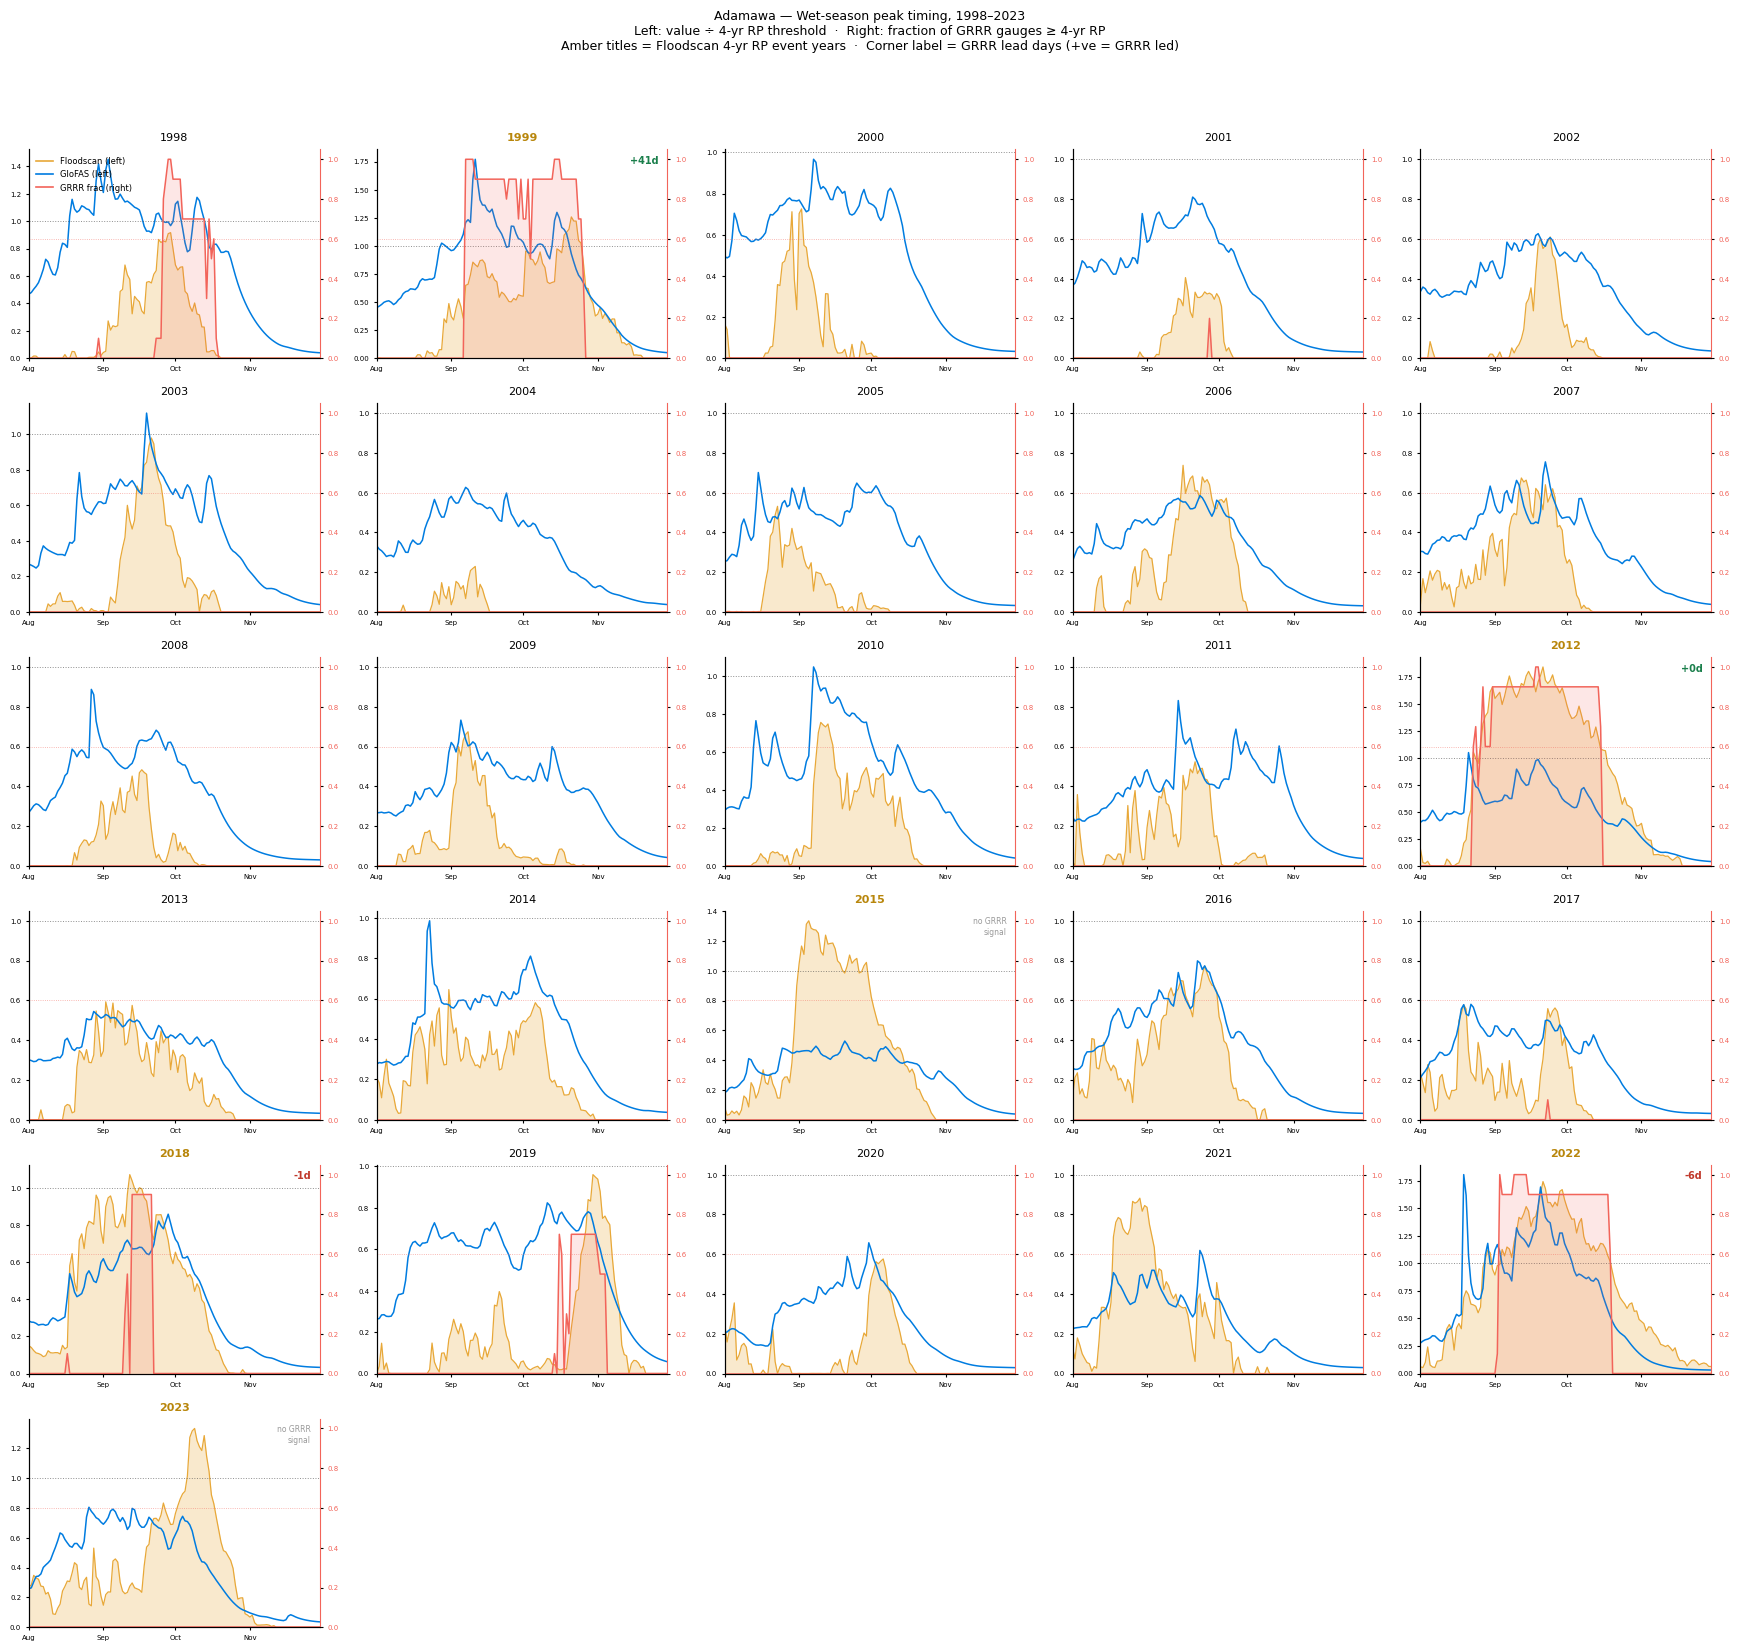


Lead-time summary for Floodscan 4-yr RP event years:
     fs_first_exceed grrr_first_60pct  lead_days
year                                            
1999      1999-10-18       1999-09-07       41.0
2012      2012-08-23       2012-08-23        0.0
2015      2015-09-01             None        NaN
2018      2018-09-12       2018-09-13       -1.0
2022      2022-08-28       2022-09-03       -6.0
2023      2023-10-06             None        NaN

Median lead: -0 days
Range: -6 to 41 days


In [9]:
GRRR_FRAC_THRESH = 0.60   # fraction of gauges required for GRRR signal
N_COLS = 5

all_years   = list(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1))
event_years = set(df_fs_ann[df_fs_ann[f"flood_{FS_RP}yr"] == 1]["year"])
n_years     = len(all_years)
n_rows      = int(np.ceil(n_years / N_COLS))

# ── Pre-compute GRRR daily fraction (vectorised) ───────────────────────────────
thresh_s     = pd.Series(thresh_grrr)
valid_ids    = list(thresh_grrr.keys())
df_grrr_chk  = df_grrr[
    df_grrr["month"].isin(WET_MONTHS)
    & df_grrr["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    & df_grrr["gauge_id"].isin(valid_ids)
].copy()
df_grrr_chk  = df_grrr_chk.join(thresh_s.rename("threshold"), on="gauge_id")
df_grrr_chk["exceeded"] = (df_grrr_chk["streamflow"] > df_grrr_chk["threshold"]).astype(int)
daily_frac   = df_grrr_chk.groupby("date")["exceeded"].mean()

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    n_rows, N_COLS,
    figsize=(N_COLS * 3.5, n_rows * 2.8),
    sharey=False,
)
axes_flat = np.array(axes).flatten()

lead_rows = []

for i, year in enumerate(all_years):
    ax    = axes_flat[i]
    start = pd.Timestamp(f"{year}-08-01")
    end   = pd.Timestamp(f"{year}-11-30")
    is_event = year in event_years

    # ── Floodscan ──────────────────────────────────────────────────────────────
    fs_yr = df_fs_daily[
        (df_fs_daily["date"] >= start) & (df_fs_daily["date"] <= end)
    ].sort_values("date")
    fs_date_exceed = None
    if not fs_yr.empty:
        fs_norm = fs_yr["sfed"] / thresh_fs
        ax.fill_between(fs_yr["date"], fs_norm, alpha=0.25, color="#E8A838", linewidth=0)
        ax.plot(fs_yr["date"], fs_norm, color="#E8A838", linewidth=0.9)
        exceed_fs = fs_yr["sfed"] > thresh_fs
        if exceed_fs.any():
            fs_date_exceed = fs_yr.loc[exceed_fs, "date"].iloc[0]

    # ── GloFAS reanalysis ──────────────────────────────────────────────────────
    gf_yr = df_gf[
        (df_gf["time"] >= start) & (df_gf["time"] <= end)
    ].sort_values("time")
    if not gf_yr.empty:
        ax.plot(gf_yr["time"], gf_yr["discharge"] / thresh_gf,
                color="#007CE0", linewidth=1.1)

    # ── GRRR fraction ──────────────────────────────────────────────────────────
    frac_yr = daily_frac[(daily_frac.index >= start) & (daily_frac.index <= end)]
    grrr_date_exceed = None
    if not frac_yr.empty:
        ax2 = ax.twinx()
        ax2.fill_between(frac_yr.index, frac_yr.values,
                         alpha=0.15, color="#F2645A", linewidth=0)
        ax2.plot(frac_yr.index, frac_yr.values, color="#F2645A", linewidth=1.1)
        ax2.axhline(GRRR_FRAC_THRESH, color="#F2645A", linewidth=0.6,
                    linestyle=":", alpha=0.6)
        ax2.set_ylim(0, 1.05)
        ax2.tick_params(axis="y", labelsize=5, labelcolor="#F2645A", length=2)
        ax2.spines["top"].set_visible(False)
        ax2.spines["right"].set_edgecolor("#F2645A")
        exceed_grrr = frac_yr >= GRRR_FRAC_THRESH
        if exceed_grrr.any():
            grrr_date_exceed = frac_yr[exceed_grrr].index[0]

    # ── RP reference line ──────────────────────────────────────────────────────
    ax.axhline(1.0, color="#444444", linewidth=0.7, linestyle=":", alpha=0.6)

    # ── Lead-time annotation for event years ──────────────────────────────────
    if is_event:
        if grrr_date_exceed is not None and fs_date_exceed is not None:
            lead_days = (fs_date_exceed - grrr_date_exceed).days
            sign  = "+" if lead_days >= 0 else ""
            color = "#1A7F4B" if lead_days >= 0 else "#C0392B"
            ax.text(0.97, 0.97, f"{sign}{lead_days}d",
                    transform=ax.transAxes, fontsize=7, ha="right", va="top",
                    color=color, fontweight="bold")
            lead_rows.append({
                "year": year,
                "fs_first_exceed":   fs_date_exceed.date() if fs_date_exceed else None,
                "grrr_first_60pct":  grrr_date_exceed.date() if grrr_date_exceed else None,
                "lead_days":         lead_days,
            })
        else:
            ax.text(0.97, 0.97,
                    "no GRRR\nsignal" if grrr_date_exceed is None else "no FS\nexceed",
                    transform=ax.transAxes, fontsize=5.5, ha="right", va="top",
                    color="#999999")
            lead_rows.append({
                "year": year,
                "fs_first_exceed":  fs_date_exceed.date() if fs_date_exceed else None,
                "grrr_first_60pct": grrr_date_exceed.date() if grrr_date_exceed else None,
                "lead_days":        None,
            })

    # ── Formatting ─────────────────────────────────────────────────────────────
    ax.set_title(
        str(year),
        fontsize=8,
        fontweight="bold" if is_event else "normal",
        color="#B8860B" if is_event else "black",
    )
    ax.set_xlim(start, end)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.tick_params(labelsize=5, length=2)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes_flat[n_years:]:
    ax.set_visible(False)

# One shared legend in the first panel
axes_flat[0].plot([], [], color="#E8A838", linewidth=1.2, label="Floodscan (left)")
axes_flat[0].plot([], [], color="#007CE0", linewidth=1.2, label="GloFAS (left)")
axes_flat[0].plot([], [], color="#F2645A", linewidth=1.2, label="GRRR frac (right)")
axes_flat[0].legend(frameon=False, fontsize=6, loc="upper left")

fig.suptitle(
    f"{STATE} — Wet-season peak timing, {ANALYSIS_START_YEAR}–{ANALYSIS_END_YEAR}\n"
    f"Left: value ÷ {FS_RP}-yr RP threshold  ·  Right: fraction of GRRR gauges ≥ {FS_RP}-yr RP\n"
    f"Amber titles = Floodscan {FS_RP}-yr RP event years  ·  Corner label = GRRR lead days (+ve = GRRR led)",
    fontsize=9,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(
    FIGURES_DIR / f"exploration_peak_timing_all_years_fs{FS_RP}yr.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

# ── Lead-time summary table ────────────────────────────────────────────────────
if lead_rows:
    df_lead = pd.DataFrame(lead_rows).set_index("year")
    print(f"\nLead-time summary for Floodscan {FS_RP}-yr RP event years:")
    print(df_lead.to_string())
    valid = df_lead["lead_days"].dropna()
    if not valid.empty:
        print(f"\nMedian lead: {valid.median():.0f} days")
        print(f"Range: {valid.min():.0f} to {valid.max():.0f} days")

## Detailed Per-Event-Year Plots with News Annotations

One full-size plot per Floodscan ≥4-yr RP event year, plus **false positive years** (1998, 2019) where the GRRR trigger fired but Floodscan did not record a ≥4-yr RP event. Same series as the overview grid (Floodscan amber fill, GloFAS blue line, GRRR fraction coral line/fill). Grey dashed vertical lines mark **flood dates sourced from news/humanitarian reports** (see sources list below each plot).

**Sources used:**
- **1999** — Limited web coverage; no specific dated reports found.
- **2012** — [2012 Nigeria floods – Wikipedia](https://en.wikipedia.org/wiki/2012_Nigeria_floods) · [Nigeria PDNA 2012 – GFDRR](https://www.gfdrr.org/sites/default/files/publication/pda-2012-nigeria.pdf)
- **2015** — [Flood: Nigeria awaits Lagdo dam release – Vanguard (Sep 2015)](https://www.vanguardngr.com/2015/09/flood-as-nigeria-awaits-release-of-water-from-lagdo-dam/amp/) · [NEMA: Adamawa/Taraba communities displaced – Blueprint](https://blueprint.ng/lagdo-dam-adamawa-taraba-benue-communities-displaced-more-to-follow-nema-raises-alarm/)
- **2018** — [NEMA Situation Report No. 2, 24 Sep 2018 – ReliefWeb](https://reliefweb.int/report/nigeria/national-emergency-management-agency-2018-floods-situation-report-no-2-24-september) · [ACAPS Briefing Note 21 Sep 2018 – ReliefWeb](https://reliefweb.int/report/nigeria/acaps-briefing-note-nigeria-floods-21-september-2018)
- **2022** — [Nigeria Floods Sep 2022 – FloodList](https://floodlist.com/africa/nigeria-floods-september-2022) · [2022 Adamawa State flood – Wikipedia](https://en.wikipedia.org/wiki/2022_Adamawa_State_flood) · [RNA Adamawa Floods Oct 2022 – ReliefWeb](https://reliefweb.int/report/nigeria/rapid-needs-assessment-rna-adamawa-floods-october-2022)
- **2023** — [Flash Report 16 Oct 2023 – ReliefWeb](https://reliefweb.int/report/nigeria/flash-report-flood-and-heavy-rainfall-north-east-nigeria-adamawa-state-16-october-2023) · [UNICEF Sitrep 31 Oct 2023 – ReliefWeb](https://reliefweb.int/report/nigeria/unicef-nigeria-humanitarian-situation-report-adamawa-flood-response-31-october-2023) · [North-East Nigeria Flood Incidents Oct 2023 – ReliefWeb](https://reliefweb.int/report/nigeria/north-east-nigeria-flood-adamawa-state-october-2023)

**False positive years (no Floodscan ≥4-yr RP event):**
- **1998** — No specific dated reports found.
- **2019** — No specific dated reports found.</cell id="30d94c78">
</invoke>

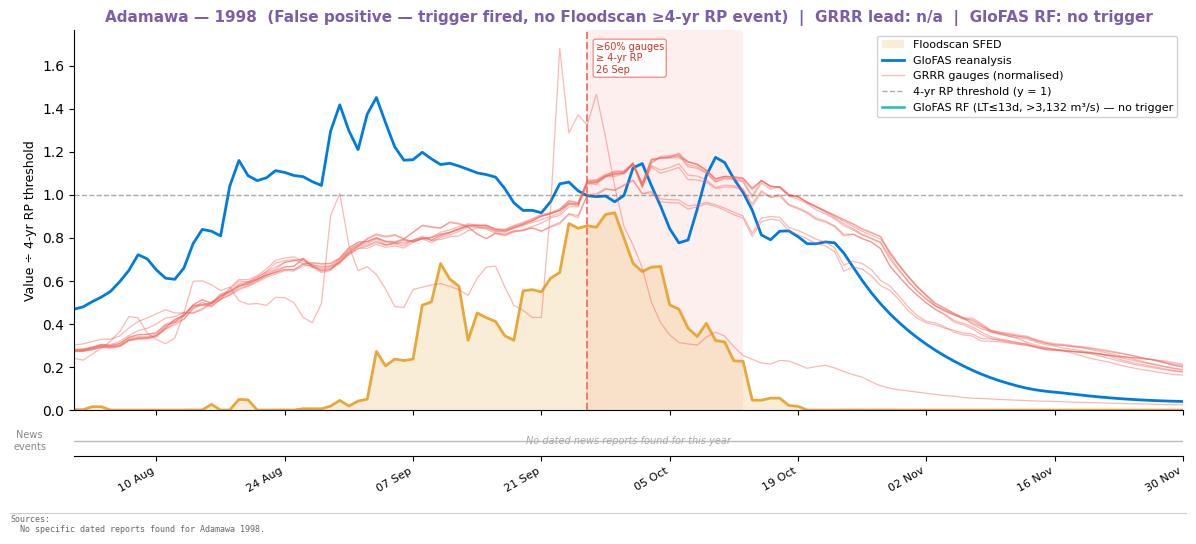

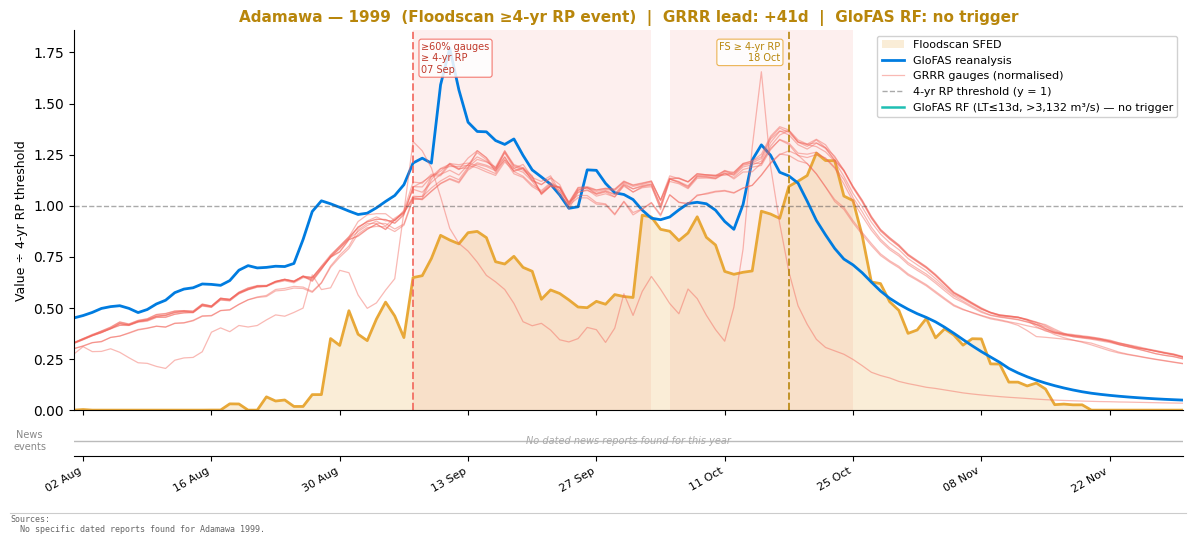

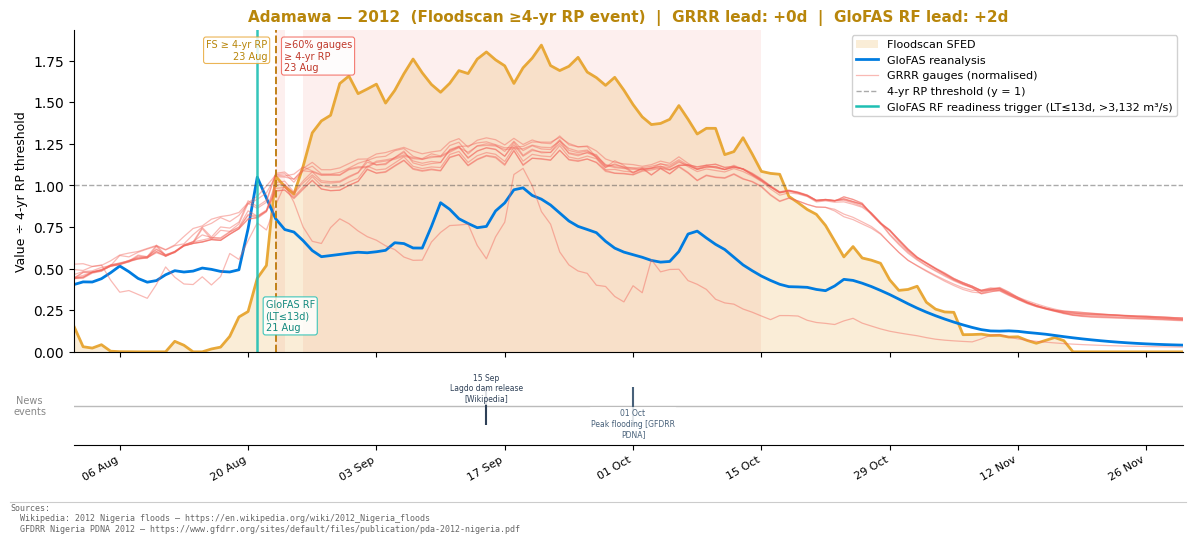

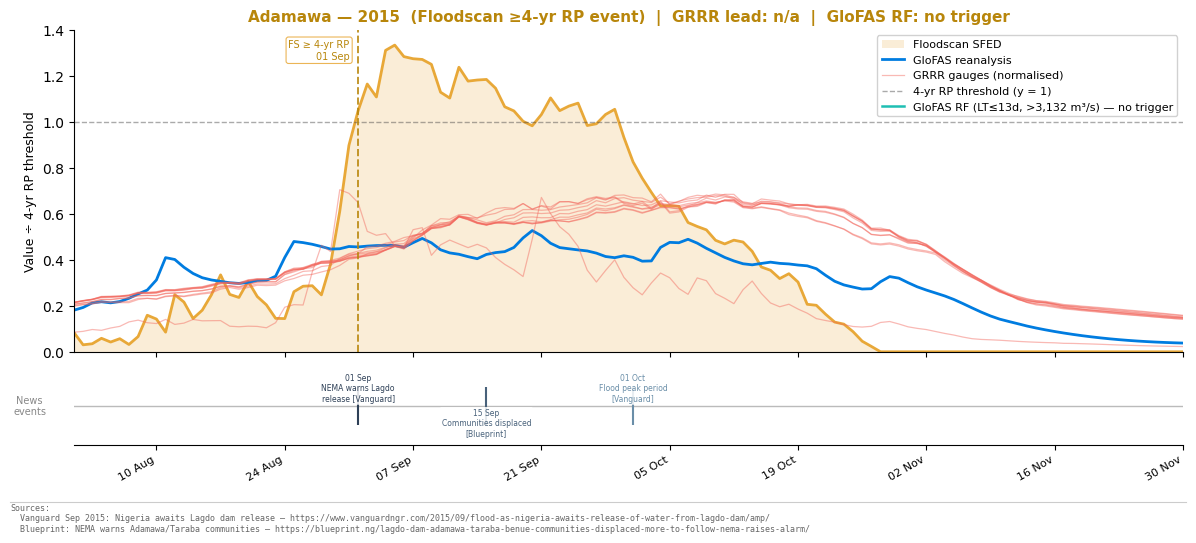

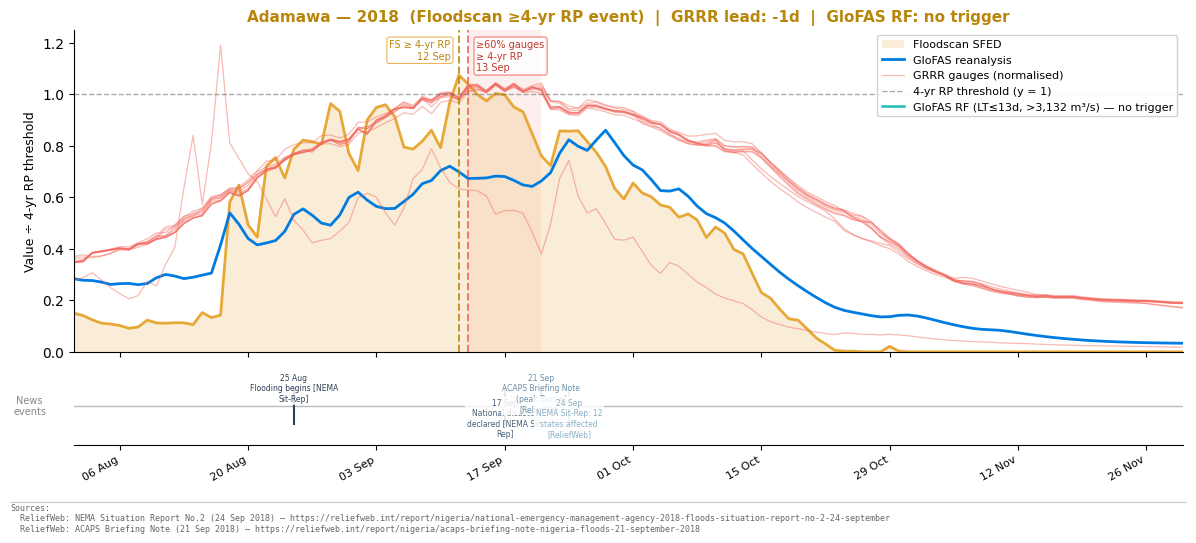

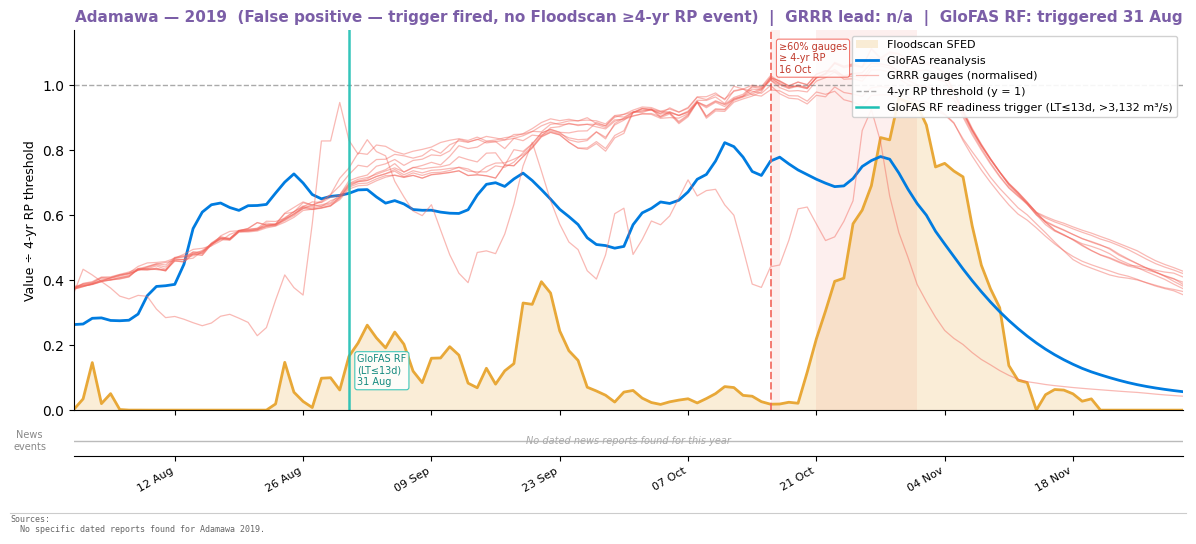

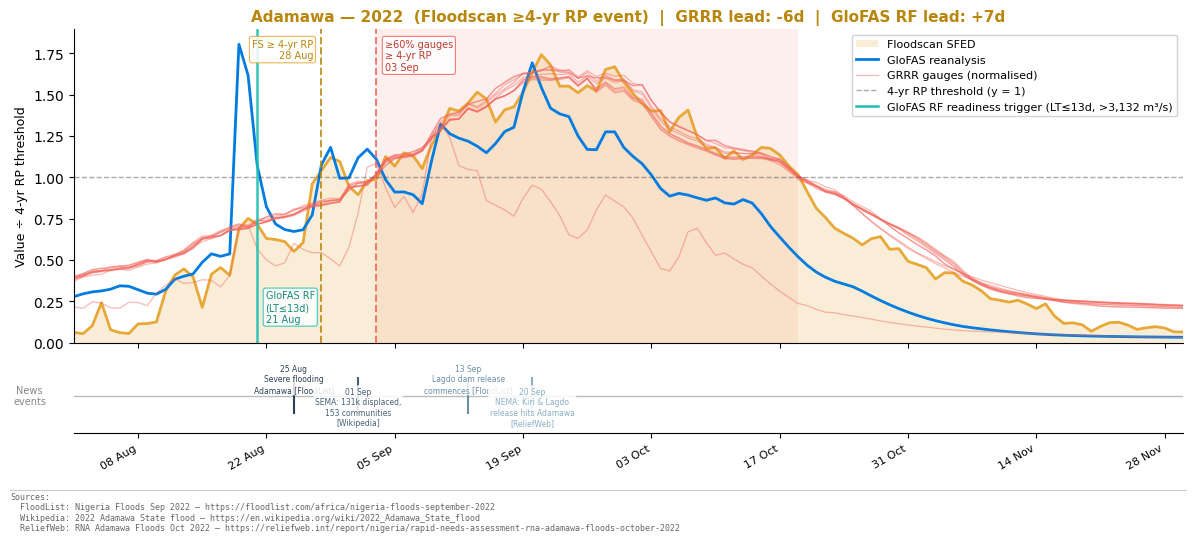

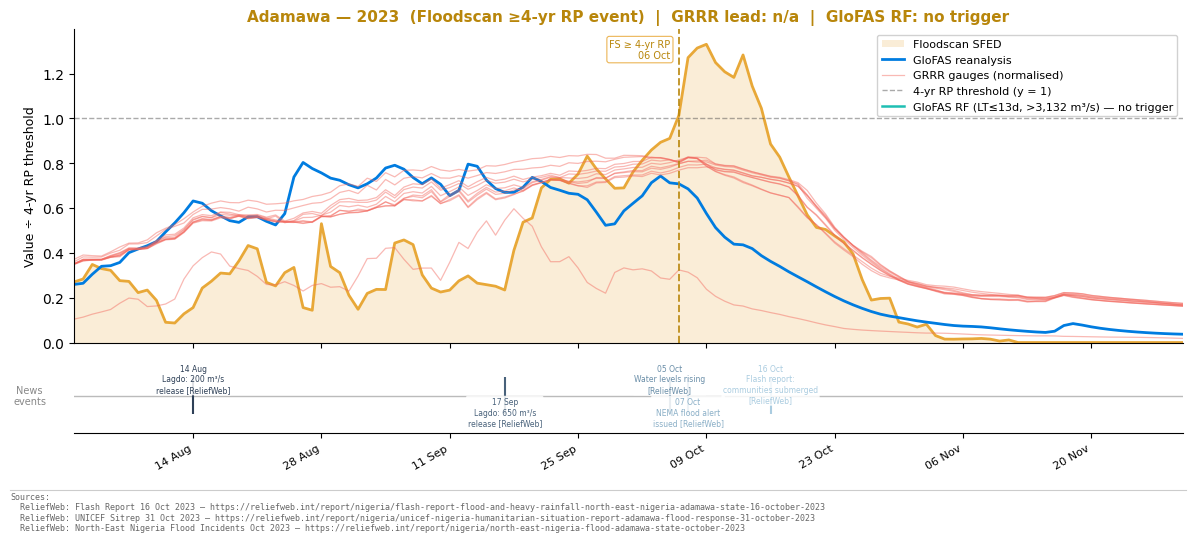

In [14]:
# News-sourced flood dates per event year
# Each entry: (date_str, label, source_tag)
NEWS_DATES = {
    1998: [],
    1999: [],
    2012: [
        ("2012-07-01", "Flooding begins",    "Wikipedia"),
        ("2012-09-15", "Lagdo dam release",  "Wikipedia"),
        ("2012-10-01", "Peak flooding",      "GFDRR PDNA"),
    ],
    2015: [
        ("2015-09-01", "NEMA warns Lagdo release",  "Vanguard"),
        ("2015-09-15", "Communities displaced",      "Blueprint"),
        ("2015-10-01", "Flood peak period",          "Vanguard"),
    ],
    2018: [
        ("2018-08-25", "Flooding begins",                  "NEMA Sit-Rep"),
        ("2018-09-17", "National disaster declared",        "NEMA Sit-Rep"),
        ("2018-09-21", "ACAPS Briefing Note (peak Benue)", "ReliefWeb"),
        ("2018-09-24", "NEMA Sit-Rep: 12 states affected", "ReliefWeb"),
    ],
    2019: [],
    2022: [
        ("2022-08-25", "Severe flooding Adamawa",             "FloodList"),
        ("2022-09-01", "SEMA: 131k displaced, 153 communities", "Wikipedia"),
        ("2022-09-13", "Lagdo dam release commences",          "FloodList"),
        ("2022-09-20", "NEMA: Kiri & Lagdo release hits Adamawa", "ReliefWeb"),
    ],
    2023: [
        ("2023-08-14", "Lagdo: 200 m³/s release",          "ReliefWeb"),
        ("2023-09-17", "Lagdo: 650 m³/s release",          "ReliefWeb"),
        ("2023-10-05", "Water levels rising",               "ReliefWeb"),
        ("2023-10-07", "NEMA flood alert issued",           "ReliefWeb"),
        ("2023-10-16", "Flash report: communities submerged", "ReliefWeb"),
    ],
}

NEWS_SOURCES = {
    1998: ["No specific dated reports found for Adamawa 1998."],
    1999: ["No specific dated reports found for Adamawa 1999."],
    2012: [
        "Wikipedia: 2012 Nigeria floods — https://en.wikipedia.org/wiki/2012_Nigeria_floods",
        "GFDRR Nigeria PDNA 2012 — https://www.gfdrr.org/sites/default/files/publication/pda-2012-nigeria.pdf",
    ],
    2015: [
        "Vanguard Sep 2015: Nigeria awaits Lagdo dam release — https://www.vanguardngr.com/2015/09/flood-as-nigeria-awaits-release-of-water-from-lagdo-dam/amp/",
        "Blueprint: NEMA warns Adamawa/Taraba communities — https://blueprint.ng/lagdo-dam-adamawa-taraba-benue-communities-displaced-more-to-follow-nema-raises-alarm/",
    ],
    2018: [
        "ReliefWeb: NEMA Situation Report No.2 (24 Sep 2018) — https://reliefweb.int/report/nigeria/national-emergency-management-agency-2018-floods-situation-report-no-2-24-september",
        "ReliefWeb: ACAPS Briefing Note (21 Sep 2018) — https://reliefweb.int/report/nigeria/acaps-briefing-note-nigeria-floods-21-september-2018",
    ],
    2019: ["No specific dated reports found for Adamawa 2019."],
    2022: [
        "FloodList: Nigeria Floods Sep 2022 — https://floodlist.com/africa/nigeria-floods-september-2022",
        "Wikipedia: 2022 Adamawa State flood — https://en.wikipedia.org/wiki/2022_Adamawa_State_flood",
        "ReliefWeb: RNA Adamawa Floods Oct 2022 — https://reliefweb.int/report/nigeria/rapid-needs-assessment-rna-adamawa-floods-october-2022",
    ],
    2023: [
        "ReliefWeb: Flash Report 16 Oct 2023 — https://reliefweb.int/report/nigeria/flash-report-flood-and-heavy-rainfall-north-east-nigeria-adamawa-state-16-october-2023",
        "ReliefWeb: UNICEF Sitrep 31 Oct 2023 — https://reliefweb.int/report/nigeria/unicef-nigeria-humanitarian-situation-report-adamawa-flood-response-31-october-2023",
        "ReliefWeb: North-East Nigeria Flood Incidents Oct 2023 — https://reliefweb.int/report/nigeria/north-east-nigeria-flood-adamawa-state-october-2023",
    ],
}

FALSE_POSITIVE_YEARS = [1998, 2019]
COLORS_NEWS = ["#2E4057", "#48617A", "#6A8EA8", "#8AAFC7", "#AACCE0"]

# Pre-compute normalised GRRR gauge series across all years
thresh_s  = pd.Series(thresh_grrr)
valid_ids = list(thresh_grrr.keys())
df_grrr_norm = df_grrr[
    df_grrr["month"].isin(WET_MONTHS)
    & df_grrr["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    & df_grrr["gauge_id"].isin(valid_ids)
].copy()
df_grrr_norm = df_grrr_norm.join(thresh_s.rename("threshold"), on="gauge_id")
df_grrr_norm["norm"] = df_grrr_norm["streamflow"] / df_grrr_norm["threshold"]

years_to_plot = sorted(set(event_years) | set(FALSE_POSITIVE_YEARS))

for year in years_to_plot:
    is_fp = year in FALSE_POSITIVE_YEARS
    start = pd.Timestamp(f"{year}-08-01")
    end   = pd.Timestamp(f"{year}-11-30")

    news_entries = NEWS_DATES.get(year, [])
    sources      = NEWS_SOURCES.get(year, [])
    source_lines = ["Sources:"] + [f"  {s}" for s in sources]
    footer_text  = "\n".join(source_lines)

    has_news      = any(start <= pd.Timestamp(d) <= end for d, _, __ in news_entries)
    height_ratios = [5, 1.2] if has_news else [5, 0.4]

    fig, (ax, ax_tl) = plt.subplots(
        2, 1,
        figsize=(12, 5.5),
        gridspec_kw={"height_ratios": height_ratios},
        sharex=True,
    )

    # ── Floodscan ──────────────────────────────────────────────────────────────
    fs_yr = df_fs_daily[
        (df_fs_daily["date"] >= start) & (df_fs_daily["date"] <= end)
    ].sort_values("date")
    fs_date_exceed = None
    if not fs_yr.empty:
        fs_norm = fs_yr["sfed"] / thresh_fs
        ax.fill_between(fs_yr["date"], fs_norm, alpha=0.20, color="#E8A838", linewidth=0,
                        label="Floodscan SFED")
        ax.plot(fs_yr["date"], fs_norm, color="#E8A838", linewidth=2.0)
        exceed_fs = fs_yr["sfed"] > thresh_fs
        if exceed_fs.any():
            fs_date_exceed = fs_yr.loc[exceed_fs, "date"].iloc[0]

    # ── GloFAS reanalysis ──────────────────────────────────────────────────────
    gf_yr = df_gf[
        (df_gf["time"] >= start) & (df_gf["time"] <= end)
    ].sort_values("time")
    if not gf_yr.empty:
        ax.plot(gf_yr["time"], gf_yr["discharge"] / thresh_gf,
                color="#007CE0", linewidth=2.0, label="GloFAS reanalysis")

    # ── Individual GRRR gauge lines (normalised to each gauge's RP threshold) ──
    grrr_yr = df_grrr_norm[
        (df_grrr_norm["date"] >= start) & (df_grrr_norm["date"] <= end)
    ]
    first_grrr_label = True
    for gid, grp in grrr_yr.groupby("gauge_id"):
        grp = grp.sort_values("date")
        lbl = "GRRR gauges (normalised)" if first_grrr_label else "_nolegend_"
        ax.plot(grp["date"], grp["norm"],
                color="#F2645A", linewidth=0.9, alpha=0.45, label=lbl)
        first_grrr_label = False

    # ── Shade periods where ≥ 60% of gauges exceed their RP threshold ─────────
    frac_yr = daily_frac[(daily_frac.index >= start) & (daily_frac.index <= end)]
    grrr_date_60pct = None
    if not frac_yr.empty:
        above = frac_yr >= GRRR_FRAC_THRESH
        ax.fill_between(
            frac_yr.index, 0, 999,
            where=above.values,
            alpha=0.10, color="#F2645A", zorder=0, linewidth=0,
            transform=ax.get_xaxis_transform(),
        )
        if above.any():
            grrr_date_60pct = frac_yr[above].index[0]
            ax.axvline(grrr_date_60pct, color="#F2645A", linewidth=1.4,
                       linestyle="--", alpha=0.85)
            ax.annotate(
                f"≥60% gauges\n≥ {FS_RP}-yr RP\n{grrr_date_60pct.strftime('%d %b')}",
                xy=(grrr_date_60pct, 0.97),
                xycoords=("data", "axes fraction"),
                xytext=(6, 0), textcoords="offset points",
                fontsize=7, color="#C0392B", va="top",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#F2645A",
                          alpha=0.85, linewidth=0.8),
            )

    # ── RP threshold reference line ────────────────────────────────────────────
    ax.axhline(1.0, color="#444444", linewidth=1.0, linestyle="--", alpha=0.45,
               label=f"{FS_RP}-yr RP threshold (y = 1)")

    # ── First Floodscan exceedance marker ──────────────────────────────────────
    if fs_date_exceed is not None:
        ax.axvline(fs_date_exceed, color="#B8860B", linewidth=1.4,
                   linestyle="--", alpha=0.85)
        ax.annotate(
            f"FS ≥ {FS_RP}-yr RP\n{fs_date_exceed.strftime('%d %b')}",
            xy=(fs_date_exceed, 0.97),
            xycoords=("data", "axes fraction"),
            xytext=(-6, 0), textcoords="offset points",
            fontsize=7, color="#B8860B", va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#E8A838",
                      alpha=0.85, linewidth=0.8),
        )

    # ── GloFAS reforecast readiness trigger ────────────────────────────────────
    gf_rf_trigger_date = None
    yr_rf_exceed = df_gf_rf_ens[
        (df_gf_rf_ens["year"] == year)
        & (df_gf_rf_ens["issue_time"] >= start)
        & (df_gf_rf_ens["issue_time"] <= end)
        & (df_gf_rf_ens["leadtime"] <= GLOFAS_RF_LEADTIME)
        & (df_gf_rf_ens["discharge"] > GLOFAS_RF_THRESH)
    ]
    if not yr_rf_exceed.empty:
        gf_rf_trigger_date = yr_rf_exceed["issue_time"].min()
        ax.axvline(gf_rf_trigger_date, color="#1EBFB3", linewidth=1.8,
                   linestyle="-", alpha=0.9)
        ax.annotate(
            f"GloFAS RF\n(LT≤{GLOFAS_RF_LEADTIME}d)\n{gf_rf_trigger_date.strftime('%d %b')}",
            xy=(gf_rf_trigger_date, 0.06),
            xycoords=("data", "axes fraction"),
            xytext=(6, 0), textcoords="offset points",
            fontsize=7, color="#148A7F", va="bottom",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#1EBFB3",
                      alpha=0.85, linewidth=0.8),
        )

    # ── Main axis formatting ───────────────────────────────────────────────────
    ax.set_xlim(start, end)
    ax.set_ylim(bottom=0)
    ax.set_ylabel(f"Value ÷ {FS_RP}-yr RP threshold", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelbottom=False)
    # Add proxy for GloFAS RF trigger so it appears in the legend
    rf_label = (
        f"GloFAS RF readiness trigger (LT≤{GLOFAS_RF_LEADTIME}d, >{GLOFAS_RF_THRESH:,.0f} m³/s)"
        if gf_rf_trigger_date is not None
        else f"GloFAS RF (LT≤{GLOFAS_RF_LEADTIME}d, >{GLOFAS_RF_THRESH:,.0f} m³/s) — no trigger"
    )
    ax.plot([], [], color="#1EBFB3", linewidth=1.8, linestyle="-", label=rf_label)
    lines, labels = ax.get_legend_handles_labels()
    ax.legend(lines, labels, loc="upper right", frameon=True, fontsize=8,
              framealpha=0.9, edgecolor="#CCCCCC")

    # ── Title ─────────────────────────────────────────────────────────────────
    if grrr_date_60pct is not None and fs_date_exceed is not None:
        lead_days = (fs_date_exceed - grrr_date_60pct).days
        sign      = "+" if lead_days >= 0 else ""
        lead_str  = f"  |  GRRR lead: {sign}{lead_days}d"
    else:
        lead_str  = "  |  GRRR lead: n/a"

    if gf_rf_trigger_date is not None and fs_date_exceed is not None:
        rf_lead  = (fs_date_exceed - gf_rf_trigger_date).days
        rf_sign  = "+" if rf_lead >= 0 else ""
        lead_str += f"  |  GloFAS RF lead: {rf_sign}{rf_lead}d"
    elif gf_rf_trigger_date is not None:
        lead_str += f"  |  GloFAS RF: triggered {gf_rf_trigger_date.strftime('%d %b')}"
    else:
        lead_str += "  |  GloFAS RF: no trigger"

    if is_fp:
        year_label  = f"(False positive — trigger fired, no Floodscan ≥{FS_RP}-yr RP event)"
        title_color = "#7B5EA7"
    else:
        year_label  = f"(Floodscan ≥{FS_RP}-yr RP event)"
        title_color = "#B8860B"

    ax.set_title(
        f"{STATE} — {year}  {year_label}{lead_str}",
        fontsize=11, fontweight="bold", color=title_color,
    )

    # ── Timeline subplot ───────────────────────────────────────────────────────
    ax_tl.set_xlim(start, end)
    ax_tl.set_ylim(0, 1)
    ax_tl.set_yticks([])
    ax_tl.spines[["left", "right", "top"]].set_visible(False)
    ax_tl.axhline(0.5, color="#BBBBBB", linewidth=1.0, zorder=0)

    visible_news = [
        (pd.Timestamp(d), lbl, src)
        for d, lbl, src in news_entries
        if start <= pd.Timestamp(d) <= end
    ]
    for k, (nd, label, source_tag) in enumerate(visible_news):
        col    = COLORS_NEWS[k % len(COLORS_NEWS)]
        y_text = 0.92 if k % 2 == 0 else 0.08
        va     = "top"  if k % 2 == 0 else "bottom"
        ax_tl.vlines(nd, ymin=0.25, ymax=0.75, color=col, linewidth=1.5, zorder=2)
        wrapped = textwrap.fill(f"{label} [{source_tag}]", width=22)
        ax_tl.text(nd, y_text,
                   f"{nd.strftime('%d %b')}\n{wrapped}",
                   fontsize=5.5, color=col, ha="center", va=va, zorder=3,
                   bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))

    if not visible_news:
        ax_tl.text(0.5, 0.5, "No dated news reports found for this year",
                   transform=ax_tl.transAxes, fontsize=7, color="#AAAAAA",
                   ha="center", va="center", style="italic")

    ax_tl.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    ax_tl.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    plt.setp(ax_tl.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
    ax_tl.set_ylabel("News\nevents", fontsize=7, color="#888888", rotation=0,
                     labelpad=32, va="center")

    # ── Footer ─────────────────────────────────────────────────────────────────
    footer_frac = len(source_lines) * 0.020 + 0.025
    plt.tight_layout(rect=[0, footer_frac, 1, 1], h_pad=0.5)
    sep_y = footer_frac - 0.007
    fig.add_artist(
        plt.matplotlib.lines.Line2D(
            [0.01, 0.99], [sep_y, sep_y],
            transform=fig.transFigure, color="#CCCCCC", linewidth=0.8,
        )
    )
    fig.text(
        0.01, sep_y - 0.003,
        footer_text,
        fontsize=6, color="#666666", va="top", ha="left", fontfamily="monospace",
    )

    suffix = "fp" if is_fp else "detail"
    plt.savefig(
        FIGURES_DIR / f"exploration_peak_timing_{year}_{suffix}.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()
    print()
